# CNN Image Classification on CIFAR-10
### Deep Learning Project | KTU | Python & TensorFlow
**Dataset:** CIFAR-10 (60,000 images, 10 classes)  
**Model:** Convolutional Neural Network (CNN)

## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('All libraries imported successfully!')

I0000 00:00:1774464278.008917    5106 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774464278.009697    5106 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774464278.077045    5106 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774464279.691446    5106 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0
All libraries imported successfully!


## Step 2: Load and Explore the CIFAR-10 Dataset

In [2]:
# Load CIFAR-10 dataset (auto-downloads if not present)
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Class names for CIFAR-10
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print('Training data shape  :', x_train.shape)
print('Training labels shape:', y_train.shape)
print('Test data shape      :', x_test.shape)
print('Test labels shape    :', y_test.shape)
print('Number of classes    :', len(class_names))
print('Classes              :', class_names)

Training data shape  : (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape      : (10000, 32, 32, 3)
Test labels shape    : (10000, 1)
Number of classes    : 10
Classes              : ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


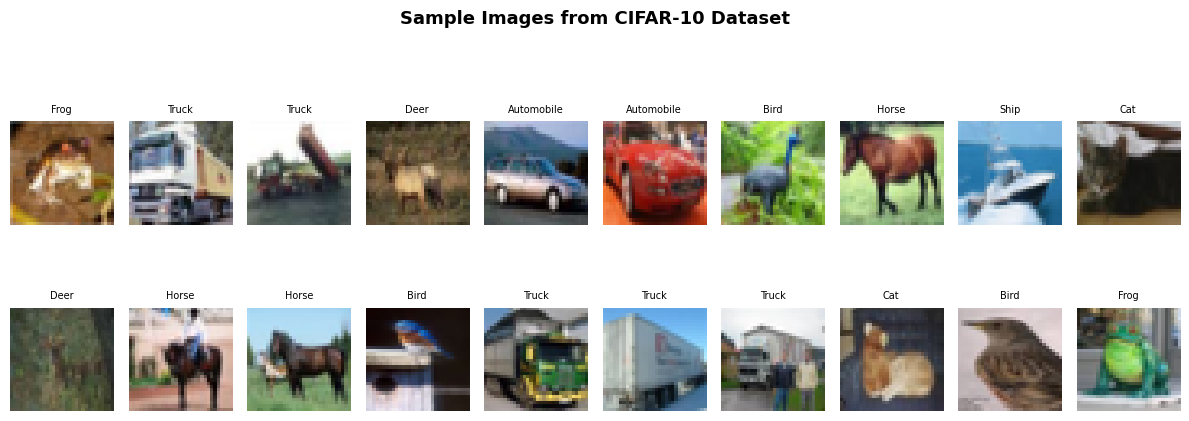

Sample images saved!


In [3]:
# Visualize sample images from the dataset
plt.figure(figsize=(12, 5))
for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=7)
    plt.axis('off')
plt.suptitle('Sample Images from CIFAR-10 Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample images saved!')

## Step 3: Preprocess the Data

In [4]:
# Normalize pixel values from [0, 255] to [0.0, 1.0]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Convert labels to one-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test,  10)

print('Pixel value range after normalization: [{:.1f}, {:.1f}]'.format(x_train.min(), x_train.max()))
print('Training label shape (one-hot):', y_train_cat.shape)
print('Preprocessing complete!')

Pixel value range after normalization: [0.0, 1.0]
Training label shape (one-hot): (50000, 10)
Preprocessing complete!


In [5]:
# Data Augmentation to improve generalization
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='data_augmentation')

print('Data augmentation pipeline created!')

Data augmentation pipeline created!


E0000 00:00:1774464284.841266    5106 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Step 4: Define the CNN Architecture

In [6]:
def build_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        # Input
        layers.Input(shape=input_shape),

        # Data Augmentation (only applied during training)
        data_augmentation,

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_CIFAR10')

    return model

model = build_cnn_model()
model.summary()

Model: "CNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,04

 Total params: 1,345,066 (5.13 MB)

 Trainable params: 1,343,146 (5.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Step 5: Compile the Model

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled!')
print('Optimizer : Adam (lr=0.001)')
print('Loss      : Categorical Cross-Entropy')
print('Metric    : Accuracy')

Model compiled!
Optimizer : Adam (lr=0.001)
Loss      : Categorical Cross-Entropy
Metric    : Accuracy


## Step 6: Train the Model

In [8]:
import os
os.makedirs('screenshots', exist_ok=True)
os.makedirs('saved_model', exist_ok=True)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
checkpoint = ModelCheckpoint(
    'saved_model/best_model.keras',
    monitor='val_accuracy', save_best_only=True, verbose=1
)

# Train
history = model.fit(
    x_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print('\nTraining complete!')

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.3236 - loss: 2.1924
Epoch 1: val_accuracy improved from None to 0.50980, saving model to saved_model/best_model.keras

Epoch 1: finished saving model to saved_model/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 187ms/step - accuracy: 0.3853 - loss: 1.8565 - val_accuracy: 0.5098 - val_loss: 1.3933
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.4924 - loss: 1.4255
Epoch 2: val_accuracy did not improve from 0.50980
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 183ms/step - accuracy: 0.5155 - loss: 1.3604 - val_accuracy: 0.4696 - val_loss: 1.7724
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5687 - loss: 1.2116
Epoch 3: val_accuracy improved from 0.50980 to 0.58240, saving model to saved_model/best_model.keras

Epoch 3: finished saving model to saved_model/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 183ms/step - accuracy: 0.5804 - loss: 1.1819 - val_accuracy: 0.5824 - val_loss: 1.

## Step 7: Plot Training History

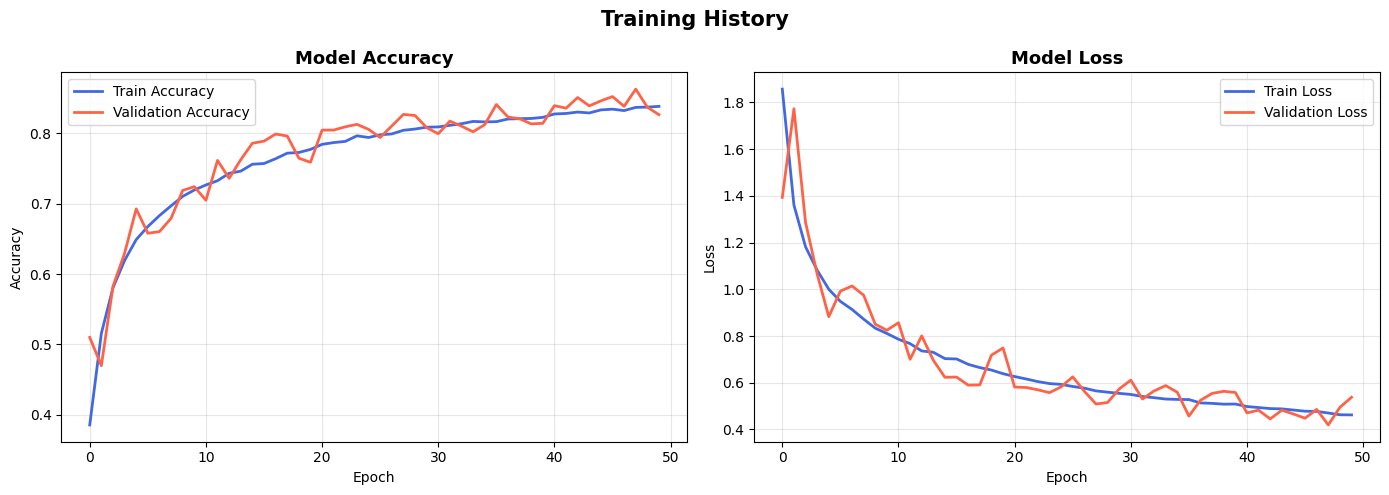

Training history plot saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='royalblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato',    linewidth=2)
axes[0].set_title('Model Accuracy',  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'],     label='Train Loss',      color='royalblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='tomato',    linewidth=2)
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training history plot saved!')

## Step 8: Evaluate the Model

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print('=' * 40)
print(f'  Test Accuracy : {test_acc * 100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 40)

  Test Accuracy : 85.70%
  Test Loss     : 0.4270


## Step 9: Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


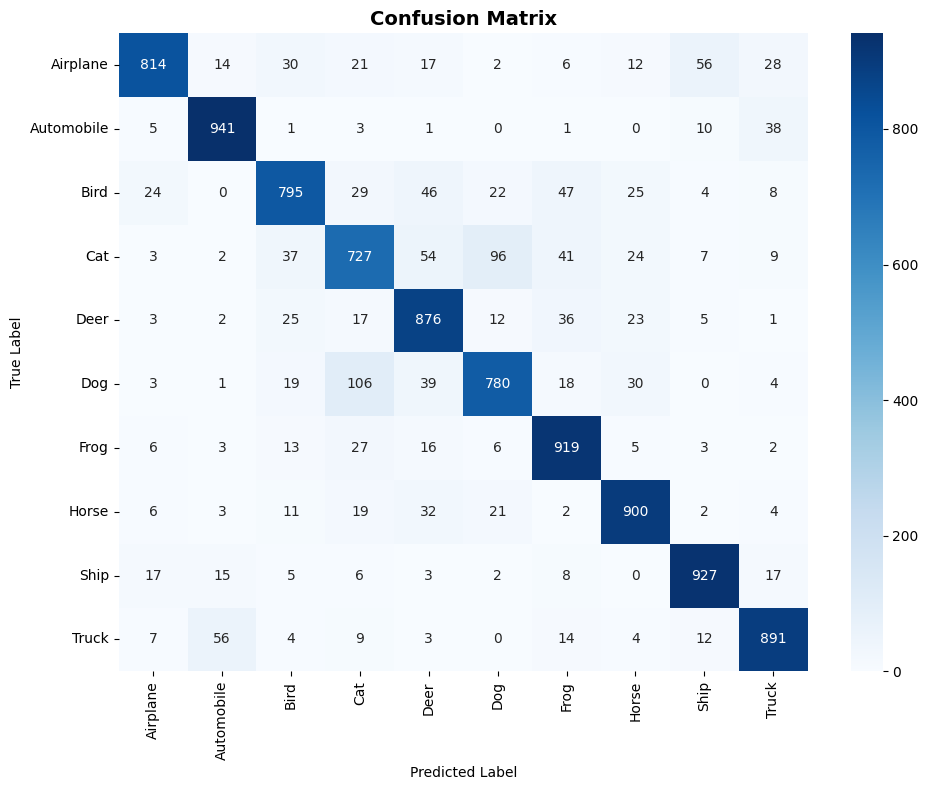


Classification Report:
              precision    recall  f1-score   support

    Airplane       0.92      0.81      0.86      1000
  Automobile       0.91      0.94      0.92      1000
        Bird       0.85      0.80      0.82      1000
         Cat       0.75      0.73      0.74      1000
        Deer       0.81      0.88      0.84      1000
         Dog       0.83      0.78      0.80      1000
        Frog       0.84      0.92      0.88      1000
       Horse       0.88      0.90      0.89      1000
        Ship       0.90      0.93      0.92      1000
       Truck       0.89      0.89      0.89      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [11]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test.flatten()

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('screenshots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

## Step 10: Predict on Sample Test Images

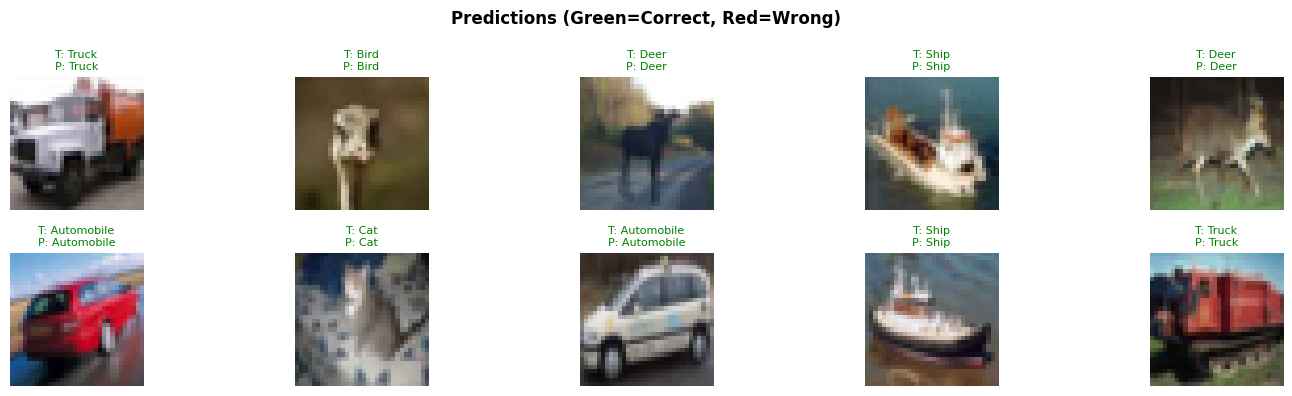

Prediction visualization saved!


In [12]:
# Pick 10 random test images and predict
import random
indices = random.sample(range(len(x_test)), 10)

plt.figure(figsize=(15, 4))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    true_label = class_names[y_test[idx][0]]
    pred_label = class_names[y_pred_classes[idx]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'T: {true_label}\nP: {pred_label}', color=color, fontsize=8)
    plt.axis('off')

plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Prediction visualization saved!')

## Done! Model saved to `saved_model/best_model.keras`

In [ ]:
# ── Change this number to anything from 0 to 9999 ──
image_number = 32

# STEP 1: Show the image only (no answer yet!)
plt.figure(figsize=(3, 3))
plt.imshow(x_test[image_number])
plt.title(f'Image #{image_number} — What is this?', fontsize=11)
plt.axis('off')
plt.show()

print("👀 Look at the image above!")
print("Options: Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck")
print()

# STEP 2: You type your guess
my_guess = input("➡ Your guess: ")

# STEP 3: Reveal the answer
img = x_test[image_number].astype('float32') / 255.0
prediction = model.predict(np.expand_dims(img, axis=0), verbose=0)
predicted_class = class_names[np.argmax(prediction)]
true_class = class_names[y_test[image_number][0]]
confidence = np.max(prediction) * 100

print()
print("=" * 35)
print(f"Correct Answer  : {true_class}")
print(f"Model Predicted : {predicted_class} ({confidence:.1f}% confidence)")
print()

if my_guess.strip().lower() == true_class.lower():
    print("YOU were right!")
else:
    print(f"You guessed wrong — it was {true_class}")

if predicted_class == true_class:
    print("Model was RIGHT!")
else:
    print("Model was WRONG too!")
print("=" * 35)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# class names
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

# load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# normalize
x_test = x_test.astype('float32') / 255.0

# LOAD MODEL (no training)
model = keras.models.load_model('saved_model/best_model.keras')
print("Model loaded!")

# choose image
image_number = 23

# STEP 1: show image
plt.figure(figsize=(3, 3))
plt.imshow(x_test[image_number])
plt.title(f'Image #{image_number} — What is this?')
plt.axis('off')
plt.show()


print("Options: Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck")

# STEP 2: manual guess (change this yourself)
my_guess = "cat"

# STEP 3: prediction
img = x_test[image_number]
prediction = model.predict(np.expand_dims(img, axis=0), verbose=0)

predicted_class = class_names[np.argmax(prediction)]
true_class = class_names[int(y_test[image_number])]
confidence = np.max(prediction) * 100

print("\n" + "="*35)
print("Correct Answer  :", true_class)
print(f"Model Predicted : {predicted_class} ({confidence:.1f}%)")

if my_guess.lower() == true_class.lower():
    print("YOU were right!")
else:
    print("You guessed wrong!")

if predicted_class == true_class:
    print("Model was RIGHT!")
else:
    print("Model was WRONG!")
print("="*35)